# LPRNet End-to-End Training for Philippine License Plates

This notebook trains a custom LPRNet tailored to the Philippine license plates. It leverages the exact same preprocessing logic used during YOLO-based plate inference, ensuring zero domain gap between training data and real-world deployment data.

## 1. Setup and Imports

In [1]:
import sys
import os

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    print("Colab detected. Installing system dependencies...")
    !apt-get update && apt-get install -y libmagickwand-dev
    !pip install matplotlib opencv-python-headless straug
else:
    print("Local environment detected. Skipping apt-get.")
    print("NOTE: If you hit ImageMagick errors on Windows, please install it manually from https://imagemagick.org/")
    !pip install matplotlib opencv-python-headless straug


Colab detected. Installing system dependencies...
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provid

In [16]:
from google.colab import drive
drive.mount('/content/drive')

# CHANGE THIS PATH if you uploaded LPRnet-keras to a different location in your Drive
import os
os.chdir('/content/drive/MyDrive/LPRnet-keras')
print("Current Directory:", os.getcwd())

Mounted at /content/drive
Current Directory: /content/drive/MyDrive/LPRnet-keras


In [3]:
import os
import sys
import cv2
import numpy as np
if not hasattr(np, 'float_'):
    np.float_ = np.float64

import glob
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.backend as K

from generator import DataGenerator, RealDataGenerator
from LPRnet.LPRnet_separable import LPRnet, CTCLoss, global_context
from gen_plates_keras import preprocess_plate

# You might need to install wandb if not in colab: !pip install wandb
# import wandb
# from wandb.keras import WandbCallback

Model: "lp_rnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ main_conv1 (SeparableConv2D)    │ (None, 24, 94, 64)     │           283 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 24, 94, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RELU1 (ReLU)                    │ (None, 24, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 24, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block               │ (None, 24, 94, 128)    │         9,600 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 24, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block_1             │ (None, 24, 47, 256)    │        35,584 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block_2             │ (None, 24, 47, 256)    │        43,904 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_conv2 (SeparableConv2D)    │ (None, 24, 24, 256)    │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_conv3 (SeparableConv2D)    │ (None, 24, 24, 36)     │        12,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 24, 24, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_out (SeparableConv2D)      │ (None, 24, 24, 36)     │        27,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,607 (771.90 KB)

 Trainable params: 194,655 (760.37 KB)

 Non-trainable params: 2,952 (11.53 KB)

## 2. Configuration

In [4]:
PROJECT_NAME = "LPRnet_keras"
MODEL_NAME = "lprnet_ph_yolo_preprocessed.keras"
MODEL_PATH = 'trained_models'
TFLITE_PATH = 'tflite_models'

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(TFLITE_PATH, exist_ok=True)

IMAGE_SHAPE = [94, 24]
CHARS = "ABCDEFGHIJKLMNPQRSTUVWXYZ0123456789" # exclude I, O if needed, adjust based on your dataset
CHARS_DICT = {char:i for i, char in enumerate(CHARS)}
DECODE_DICT = {i:char for i, char in enumerate(CHARS)}
NUM_CLASS = len(CHARS)+1

EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

## 3. Data Loading & Preprocessing

We use the customized generators that internally call `preprocess_plate()` (applying Grayscale, CLAHE, and Sharpening) to guarantee consistency.

In [5]:
import importlib
import generator
importlib.reload(generator)

from generator import DataGenerator, RealDataGenerator

# Re-instantiate your generators
train_generator = DataGenerator()
val_generator = RealDataGenerator("./valid/") # or whatever your path is

0


## 4. Visualizing Preprocessed Plates
Let's see what the preprocessed plates look like before feeding them to the model.

In [6]:
import numpy as np
import skimage.filters
import sys

# --- 1. NUMPY 2.0 PATCH ---
if not hasattr(np, 'float_'):
    np.float_ = np.float64

# --- 2. SCIKIT-IMAGE PATCH ---
_orig_gaussian = skimage.filters.gaussian
def patched_gaussian(*args, **kwargs):
    if 'multichannel' in kwargs:
        is_multi = kwargs.pop('multichannel')
        kwargs['channel_axis'] = -1 if is_multi else None
    return _orig_gaussian(*args, **kwargs)

skimage.filters.gaussian = patched_gaussian
if 'straug.blur' in sys.modules:
    sys.modules['straug.blur'].gaussian = patched_gaussian

print("Environment patches applied successfully!")

Environment patches applied successfully!


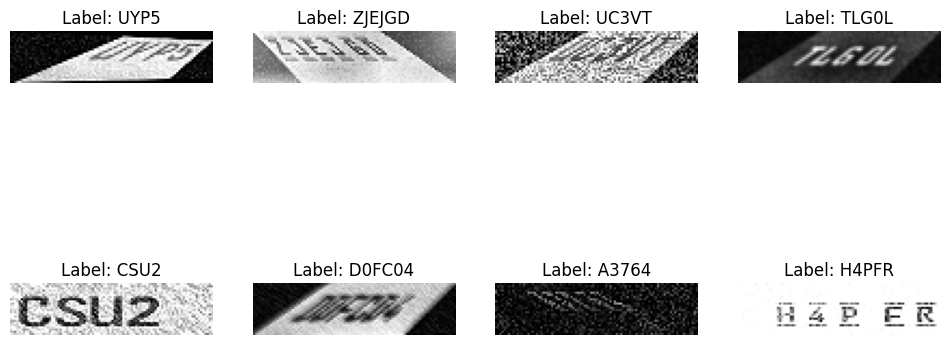

In [7]:
x_batch, y_batch = train_generator[0]

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(min(8, len(x_batch))):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_batch[i])
    label = "".join([DECODE_DICT.get(lbl, "") for lbl in y_batch[i].numpy() if lbl in DECODE_DICT])
    plt.title(f"Label: {label}")
    plt.axis('off')

## 5. Model Architecture & Compilation

In [18]:
model_save_path = os.path.join(MODEL_PATH, MODEL_NAME)

# 1. Import EVERY custom piece of your architecture
from LPRnet.LPRnet_separable import LPRnet, CTCLoss, global_context, small_basic_block

# 2. Map them explicitly so Keras knows exactly what they are
custom_mapping = {
    "LPRnet": LPRnet,
    "CTCLoss": CTCLoss,
    "global_context": global_context,
    "small_basic_block": small_basic_block
}

if os.path.exists(model_save_path):
    print("Loading existing model...")
    # 3. Force Keras to use your mapping to decode the old file
    model = keras.models.load_model(
        model_save_path,
        custom_objects=custom_mapping
    )
else:
    print("Building model from scratch...")
    model = LPRnet()
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss=CTCLoss)
    model.build((1, 24, 94, 3))

model.summary()

Loading existing model...


Model: "lp_rnet_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ main_conv1 (SeparableConv2D)    │ (None, 24, 94, 64)     │           283 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 24, 94, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RELU1 (ReLU)                    │ (None, 24, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 24, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block_3             │ (None, 24, 94, 128)    │         9,600 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 24, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block_4             │ (None, 24, 47, 256)    │        35,584 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ small_basic_block_5             │ (None, 24, 47, 256)    │        43,904 │
│ (small_basic_block)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_conv2 (SeparableConv2D)    │ (None, 24, 24, 256)    │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_conv3 (SeparableConv2D)    │ (None, 24, 24, 36)     │        12,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 24, 24, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 24, 24, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_out (SeparableConv2D)      │ (None, 24, 24, 36)     │        27,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 586,919 (2.24 MB)

 Trainable params: 194,655 (760.37 KB)

 Non-trainable params: 2,952 (11.53 KB)

 Optimizer params: 389,312 (1.49 MB)

## 6. Training Loop

In [9]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    model_save_path,
    monitor="val_loss", # use "val_loss" if using validation dataset
    verbose=1,
    save_best_only=True, # True if using validation
    save_weights_only=False,
    mode="auto",
    save_freq=500,
)

# If using Wandb:
# wandb.init(project=PROJECT_NAME, name=MODEL_NAME)
# callbacks = [checkpoint_cb, WandbCallback()]
callbacks = [checkpoint_cb]

print(f"Starting training for {EPOCHS} epochs...")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    validation_steps=20,
    epochs=EPOCHS,
    steps_per_epoch=50,
    callbacks=callbacks
)

Starting training for 100 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - loss: 31.4793 - val_loss: 77.6188
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - loss: 21.2855 - val_loss: 77.9474
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 21.2075 - val_loss: 77.7944
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - loss: 21.1794 - val_loss: 77.5531
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 21.2799 - val_loss: 77.9312
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 21.1700 - val_loss: 70.5788
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 21.2026 - val_loss: 58.7372
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - loss: 21.0992 - val_loss: 46.4749
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 21.2295 - val_loss: 36.3969
Epoch 10/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 21.1631

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 10: finished saving model to trained_models/lprnet_ph_yolo_preprocessed.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - loss: 21.1669 - val_loss: 29.3877
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 21.0813 - val_loss: 26.6249
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - loss: 21.0352 - val_loss: 24.0108
Epoch 13/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - loss: 21.0368 - val_loss: 22.1186
Epoch 14/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - loss: 21.0500 - val_loss: 21.3097
Epoch 15/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - loss: 21.0116 - val_loss: 21.0706
Epoch 16/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 21.0448 - val_loss: 21.1021
Epoch 17/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - loss: 21.0400 - val_loss: 21.0947
Epoch 18/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - loss: 20.9983 - val_loss: 21.2322
Epoch 19/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 20.8871 - val_loss: 21.0161
Epoch 20/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/st

InvalidArgumentError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  TypeError: `generator` yielded an element of shape (64, 6) where an element of shape (None, 7) was expected.
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 235, in generator_py_func
    raise TypeError(

TypeError: `generator` yielded an element of shape (64, 6) where an element of shape (None, 7) was expect

In [20]:
# 1. Define your checkpoint callback
# (This ensures your next saves use the fully updated decorators!)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    model_save_path,
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch", # 'epoch' is much safer than 500 when monitoring val_loss
)

callbacks = [checkpoint_cb]

# 2. Set the epoch you are resuming from
LAST_SAVED_EPOCH = 30

print(f"Resuming training from epoch {LAST_SAVED_EPOCH}...")

# 3. Kick off the training loop!
history = model.fit(
    train_generator,
    validation_data=val_generator,
    validation_steps=20,
    epochs=EPOCHS, # Keeps your total target at 100
    initial_epoch=LAST_SAVED_EPOCH, # <--- The magic variable
    steps_per_epoch=50,
    callbacks=callbacks
)

Resuming training from epoch 30...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 31/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 20.2471

ValueError: high <= 0

## 7. Exporting to TFLite
Once training finishes, export the model to `.tflite` format for local deployment in your C# / C++ / Python environments.

In [12]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

# Optionally apply quantization here if desired
tflite_model = converter.convert()

tflite_file_path = os.path.join(TFLITE_PATH, f"{MODEL_NAME}.tflite")
with open(tflite_file_path, 'wb') as f:
    f.write(tflite_model)

print(f"Successfully exported TFLite model to {tflite_file_path}")

Saved artifact at '/tmp/tmpq4jmgvwy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 94, 3), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 24, 36), dtype=tf.float32, name=None)
Captures:
  132122798078288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798077328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798079056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798079824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798078096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798078480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798079440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798078672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798079632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122798078864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132122795066768: Tens